# Baseline Model: TF-IDF + Logistic Regression

Este notebook implementa um modelo baseline para análise de sentimento usando:
- **Vetorização**: TF-IDF (Term Frequency-Inverse Document Frequency)
- **Classificador**: Logistic Regression

## Objetivos:
1. Carregar dados preprocessados
2. Dividir em conjuntos de treino, validação e teste
3. Treinar modelo baseline
4. Avaliar performance com múltiplas métricas
5. Gerar logs detalhados do processo


## 1. Importações e Configurações


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# Configurações de visualização
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✅ Bibliotecas importadas com sucesso!")
print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


✅ Bibliotecas importadas com sucesso!
Timestamp: 2025-11-04 17:31:53


## 2. Carregamento dos Dados


In [2]:
# Caminho para os dados preprocessados
DATA_PATH = r'C:\Users\eduar\OneDrive\Documentos\sentiment_analysis-20251104T201129Z-1-001\sentiment_analysis\data\sentiment140_preprocessed.csv'

print("="*80)
print("CARREGANDO DADOS")
print("="*80)

# Carregar dados
df = pd.read_csv(DATA_PATH)

print(f"\n✅ Dados carregados com sucesso!")
print(f"   - Total de registros: {len(df):,}")
print(f"   - Colunas: {list(df.columns)}")
print(f"   - Memória utilizada: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Informações básicas
print(f"\n📊 Informações do Dataset:")
print(df.info())

# Primeiras linhas
print(f"\n📋 Primeiras linhas:")
display(df.head(10))


CARREGANDO DADOS

✅ Dados carregados com sucesso!
   - Total de registros: 1,591,869
   - Colunas: ['text', 'label']
   - Memória utilizada: 162.82 MB

📊 Informações do Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1591869 entries, 0 to 1591868
Data columns (total 2 columns):
 #   Column  Non-Null Count    Dtype 
---  ------  --------------    ----- 
 0   text    1591869 non-null  object
 1   label   1591869 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 24.3+ MB
None

📋 Primeiras linhas:


,text,label
0,awww thats bummer shoulda got david carr third...,0
1,upset cant update facebook texting might cry r...,0
2,dived many time ball managed save rest go bound,0
3,whole body feel itchy like fire,0
4,behaving im mad cant see,0
5,whole crew,0
6,need hug,0
7,hey long time see yes rain bit bit lol im fine...,0
8,nope didnt,0
9,que muera,0


## 3. Análise Exploratória Básica


ANÁLISE EXPLORATÓRIA

📊 Distribuição das Classes:
label
0    796269
1    795600
Name: count, dtype: int64

Percentuais:
label
0    50.021013
1    49.978987
Name: proportion, dtype: float64


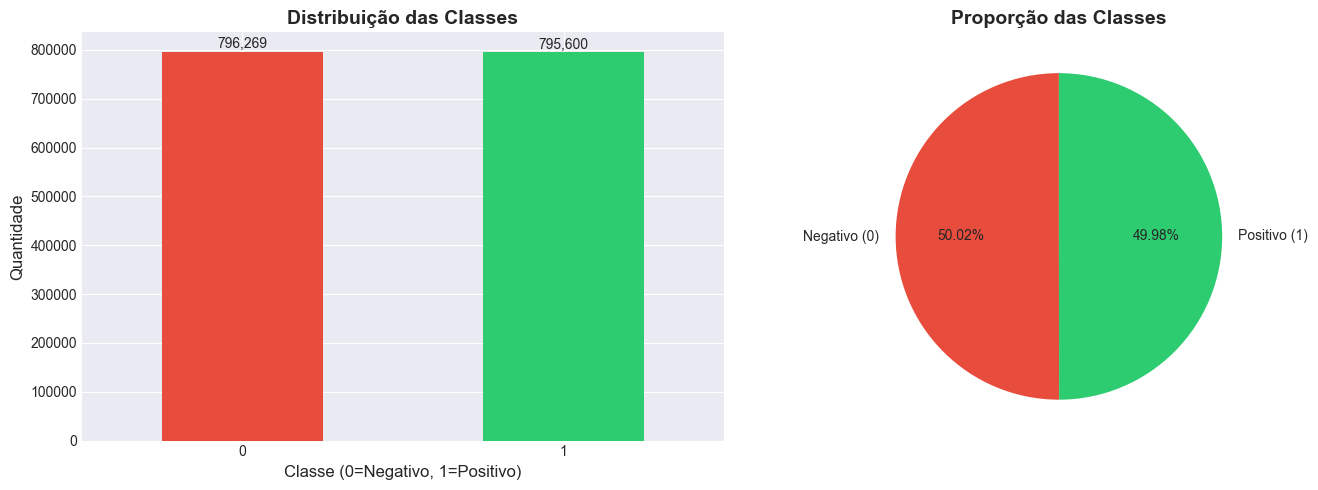


📏 Estatísticas de Comprimento:

Comprimento dos textos (caracteres):
count    1.591869e+06
mean     4.224927e+01
std      2.368276e+01
min      1.000000e+00
25%      2.300000e+01
50%      3.900000e+01
75%      5.900000e+01
max      1.730000e+02
Name: text_length, dtype: float64

Número de palavras:
count    1.591869e+06
mean     7.113657e+00
std      3.875084e+00
min      1.000000e+00
25%      4.000000e+00
50%      7.000000e+00
75%      1.000000e+01
max      3.500000e+01
Name: word_count, dtype: float64


In [3]:
print("="*80)
print("ANÁLISE EXPLORATÓRIA")
print("="*80)

# Distribuição das classes
print(f"\n📊 Distribuição das Classes:")
class_counts = df['label'].value_counts().sort_index()
print(class_counts)
print(f"\nPercentuais:")
print(df['label'].value_counts(normalize=True).sort_index() * 100)

# Visualização da distribuição
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
class_counts.plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Distribuição das Classes', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Classe (0=Negativo, 1=Positivo)', fontsize=12)
axes[0].set_ylabel('Quantidade', fontsize=12)
axes[0].tick_params(axis='x', rotation=0)

# Adicionar valores no topo das barras
for i, v in enumerate(class_counts):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', va='bottom', fontsize=10)

# Gráfico de pizza
colors = ['#e74c3c', '#2ecc71']
axes[1].pie(class_counts, labels=['Negativo (0)', 'Positivo (1)'], autopct='%1.2f%%', 
            startangle=90, colors=colors)
axes[1].set_title('Proporção das Classes', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Estatísticas de comprimento do texto
df['text_length'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()

print(f"\n📏 Estatísticas de Comprimento:")
print(f"\nComprimento dos textos (caracteres):")
print(df['text_length'].describe())
print(f"\nNúmero de palavras:")
print(df['word_count'].describe())


## 4. Divisão dos Dados (Treino, Validação, Teste)


In [4]:
print("="*80)
print("DIVISÃO DOS DADOS")
print("="*80)

# Separar features e target
X = df['text'].values
y = df['label'].values

print(f"\n📦 Dataset completo:")
print(f"   - Total de amostras: {len(X):,}")
print(f"   - Classes únicas: {np.unique(y)}")

# Primeira divisão: 70% treino, 30% temporário (validação + teste)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"\n✂️ Primeira divisão (treino vs temp):")
print(f"   - Treino: {len(X_train):,} amostras ({len(X_train)/len(X)*100:.1f}%)")
print(f"   - Temp (val+test): {len(X_temp):,} amostras ({len(X_temp)/len(X)*100:.1f}%)")

# Segunda divisão: dividir o temporário em validação e teste (50/50)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"\n✂️ Segunda divisão (validação vs teste):")
print(f"   - Validação: {len(X_val):,} amostras ({len(X_val)/len(X)*100:.1f}%)")
print(f"   - Teste: {len(X_test):,} amostras ({len(X_test)/len(X)*100:.1f}%)")

print(f"\n✅ Divisão final dos dados:")
print(f"   - Treino: {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)")
print(f"   - Validação: {len(X_val):,} ({len(X_val)/len(X)*100:.1f}%)")
print(f"   - Teste: {len(X_test):,} ({len(X_test)/len(X)*100:.1f}%)")

# Verificar distribuição das classes em cada conjunto
print(f"\n📊 Distribuição das classes:")
print(f"\nTreino:")
print(pd.Series(y_train).value_counts(normalize=True).sort_index() * 100)
print(f"\nValidação:")
print(pd.Series(y_val).value_counts(normalize=True).sort_index() * 100)
print(f"\nTeste:")
print(pd.Series(y_test).value_counts(normalize=True).sort_index() * 100)


DIVISÃO DOS DADOS

📦 Dataset completo:
   - Total de amostras: 1,591,869
   - Classes únicas: [0 1]

✂️ Primeira divisão (treino vs temp):
   - Treino: 1,114,308 amostras (70.0%)
   - Temp (val+test): 477,561 amostras (30.0%)

✂️ Segunda divisão (validação vs teste):
   - Validação: 238,780 amostras (15.0%)
   - Teste: 238,781 amostras (15.0%)

✅ Divisão final dos dados:
   - Treino: 1,114,308 (70.0%)
   - Validação: 238,780 (15.0%)
   - Teste: 238,781 (15.0%)

📊 Distribuição das classes:

Treino:
0    50.021
1    49.979
Name: proportion, dtype: float64

Validação:
0    50.02094
1    49.97906
Name: proportion, dtype: float64

Teste:
0    50.021149
1    49.978851
Name: proportion, dtype: float64


## 5. Vetorização TF-IDF


In [5]:
print("="*80)
print("VETORIZAÇÃO TF-IDF")
print("="*80)

print(f"\n⚙️ Inicializando TF-IDF Vectorizer...")

# Configuração do TF-IDF Vectorizer
tfidf_params = {
    'max_features': 10000,      # Limitar a 10000 features mais importantes
    'min_df': 5,                # Palavra deve aparecer em pelo menos 5 documentos
    'max_df': 0.8,              # Ignorar termos que aparecem em mais de 80% dos docs
    'ngram_range': (1, 2),      # Usar unigramas e bigramas
    'sublinear_tf': True        # Usar escala logarítmica para TF
}

print(f"\n📋 Parâmetros do TF-IDF:")
for param, value in tfidf_params.items():
    print(f"   - {param}: {value}")

# Criar e treinar o vetorizador
print(f"\n🔄 Ajustando vetorizador nos dados de treino...")
start_time = datetime.now()

vectorizer = TfidfVectorizer(**tfidf_params)
X_train_tfidf = vectorizer.fit_transform(X_train)

end_time = datetime.now()
duration = (end_time - start_time).total_seconds()

print(f"✅ Vetorização de treino concluída em {duration:.2f} segundos")

# Transformar validação e teste
print(f"\n🔄 Transformando conjuntos de validação e teste...")
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)
print(f"✅ Transformação concluída")

# Informações sobre as features
print(f"\n📊 Informações da Vetorização:")
print(f"   - Vocabulário: {len(vectorizer.vocabulary_):,} termos únicos")
print(f"   - Shape treino: {X_train_tfidf.shape}")
print(f"   - Shape validação: {X_val_tfidf.shape}")
print(f"   - Shape teste: {X_test_tfidf.shape}")
print(f"   - Sparsity: {(1.0 - X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1])) * 100:.2f}%")
print(f"   - Memória (treino): {X_train_tfidf.data.nbytes / 1024**2:.2f} MB")

# Top features por TF-IDF
print(f"\n🔝 Top 20 termos com maior IDF (mais discriminativos):")
feature_names = vectorizer.get_feature_names_out()
idf_scores = vectorizer.idf_
top_indices = np.argsort(idf_scores)[-20:][::-1]

for idx in top_indices:
    print(f"   - '{feature_names[idx]}': {idf_scores[idx]:.4f}")


VETORIZAÇÃO TF-IDF

⚙️ Inicializando TF-IDF Vectorizer...

📋 Parâmetros do TF-IDF:
   - max_features: 10000
   - min_df: 5
   - max_df: 0.8
   - ngram_range: (1, 2)
   - sublinear_tf: True

🔄 Ajustando vetorizador nos dados de treino...
✅ Vetorização de treino concluída em 30.18 segundos

🔄 Transformando conjuntos de validação e teste...
✅ Transformação concluída

📊 Informações da Vetorização:
   - Vocabulário: 10,000 termos únicos
   - Shape treino: (1114308, 10000)
   - Shape validação: (238780, 10000)
   - Shape teste: (238781, 10000)
   - Sparsity: 99.93%
   - Memória (treino): 60.20 MB

🔝 Top 20 termos com maior IDF (mais discriminativos):
   - 'womp': 10.8633
   - 'plz plz': 10.8633
   - 'ow ow': 10.8462
   - 'clap': 10.7341
   - 'bored bored': 10.7341
   - 'fuck fuck': 10.6611
   - 'ting': 10.6197
   - 'tired tired': 10.6197
   - 'birthday happy': 10.5670
   - 'follow follow': 10.5049
   - 'zzz': 10.4578
   - 'hate hate': 10.4351
   - 'omg omg': 10.4020
   - 'badminton': 10.3805

## 6. Treinamento do Modelo - Logistic Regression


In [6]:
print("="*80)
print("TREINAMENTO DO MODELO BASELINE")
print("="*80)

print(f"\n⚙️ Inicializando Logistic Regression...")

# Configuração do modelo
model_params = {
    'max_iter': 1000,
    'random_state': 42,
    'verbose': 1,
    'n_jobs': -1,               # Usar todos os cores disponíveis
    'solver': 'saga',           # Solver eficiente para grandes datasets
    'C': 1.0                    # Regularização
}

print(f"\n📋 Parâmetros do modelo:")
for param, value in model_params.items():
    print(f"   - {param}: {value}")

# Criar e treinar o modelo
print(f"\n🔄 Iniciando treinamento...")
print(f"   Timestamp início: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
start_time = datetime.now()

model = LogisticRegression(**model_params)
model.fit(X_train_tfidf, y_train)

end_time = datetime.now()
duration = (end_time - start_time).total_seconds()

print(f"\n✅ Treinamento concluído!")
print(f"   Timestamp fim: {end_time.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"   Duração total: {duration:.2f} segundos ({duration/60:.2f} minutos)")
print(f"   Número de iterações: {model.n_iter_[0]}")

# Informações do modelo treinado
print(f"\n📊 Informações do modelo:")
print(f"   - Classes: {model.classes_}")
print(f"   - Coeficientes shape: {model.coef_.shape}")
print(f"   - Intercept: {model.intercept_[0]:.4f}")


TREINAMENTO DO MODELO BASELINE

⚙️ Inicializando Logistic Regression...

📋 Parâmetros do modelo:
   - max_iter: 1000
   - random_state: 42
   - verbose: 1
   - n_jobs: -1
   - solver: saga
   - C: 1.0

🔄 Iniciando treinamento...
   Timestamp início: 2025-11-04 17:32:39


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.


convergence after 22 epochs took 16 seconds

✅ Treinamento concluído!
   Timestamp fim: 2025-11-04 17:32:55
   Duração total: 15.72 segundos (0.26 minutos)
   Número de iterações: 22

📊 Informações do modelo:
   - Classes: [0 1]
   - Coeficientes shape: (1, 10000)
   - Intercept: 0.5271


## 7. Avaliação no Conjunto de Validação


AVALIAÇÃO NO CONJUNTO DE VALIDAÇÃO

🔮 Gerando predições para validação...
✅ Predições geradas

📊 MÉTRICAS DE VALIDAÇÃO:
   - Accuracy:  0.7839 (78.39%)
   - Precision: 0.7730
   - Recall:    0.8035
   - F1-Score:  0.7880
   - ROC-AUC:   0.8657

📋 Classification Report (Validação):
              precision    recall  f1-score   support

Negativo (0)       0.80      0.76      0.78    119440
Positivo (1)       0.77      0.80      0.79    119340

    accuracy                           0.78    238780
   macro avg       0.78      0.78      0.78    238780
weighted avg       0.78      0.78      0.78    238780


🔢 Matriz de Confusão (Validação):
[[91285 28155]
 [23447 95893]]


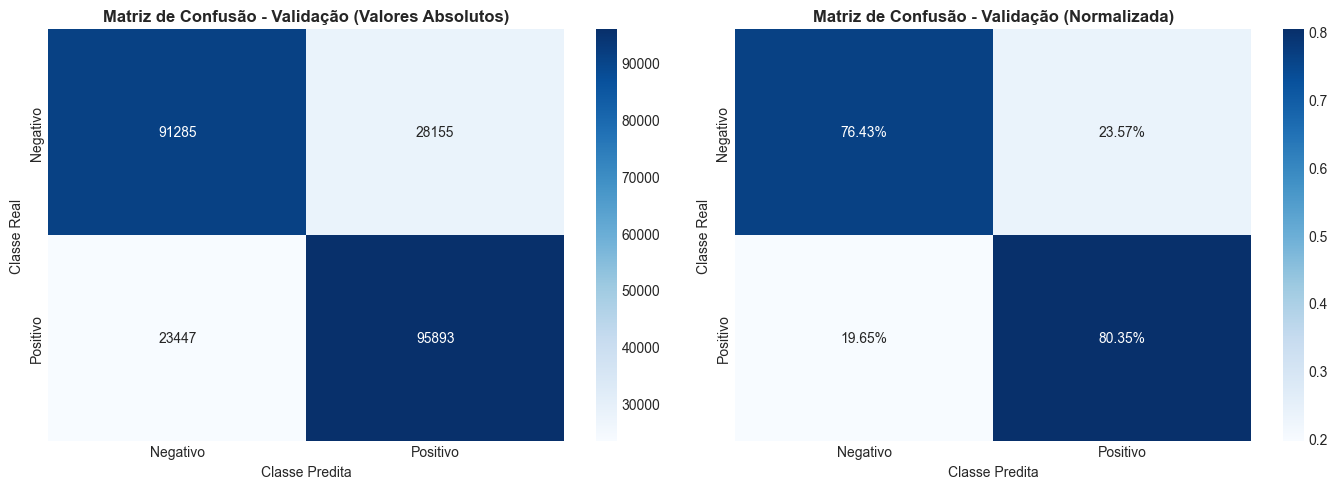

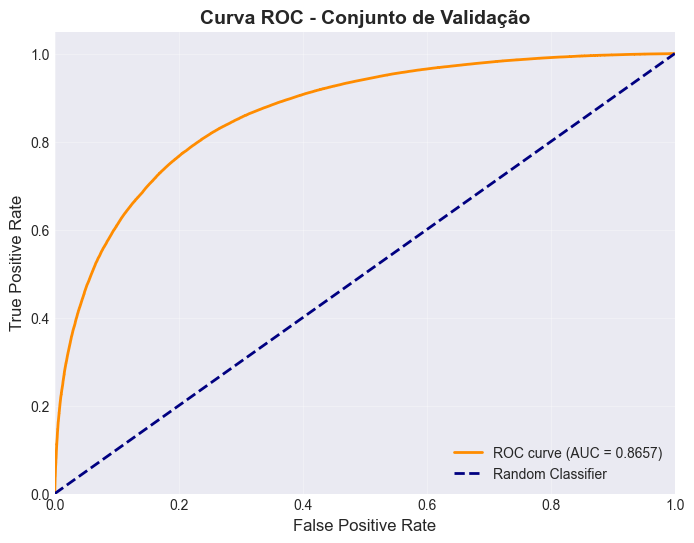

In [7]:
print("="*80)
print("AVALIAÇÃO NO CONJUNTO DE VALIDAÇÃO")
print("="*80)

# Fazer predições
print(f"\n🔮 Gerando predições para validação...")
y_val_pred = model.predict(X_val_tfidf)
y_val_proba = model.predict_proba(X_val_tfidf)[:, 1]
print(f"✅ Predições geradas")

# Calcular métricas
val_accuracy = accuracy_score(y_val, y_val_pred)
val_precision = precision_score(y_val, y_val_pred)
val_recall = recall_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred)
val_roc_auc = roc_auc_score(y_val, y_val_proba)

print(f"\n📊 MÉTRICAS DE VALIDAÇÃO:")
print(f"   - Accuracy:  {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")
print(f"   - Precision: {val_precision:.4f}")
print(f"   - Recall:    {val_recall:.4f}")
print(f"   - F1-Score:  {val_f1:.4f}")
print(f"   - ROC-AUC:   {val_roc_auc:.4f}")

# Classification Report
print(f"\n📋 Classification Report (Validação):")
print(classification_report(y_val, y_val_pred, target_names=['Negativo (0)', 'Positivo (1)']))

# Confusion Matrix
cm_val = confusion_matrix(y_val, y_val_pred)
print(f"\n🔢 Matriz de Confusão (Validação):")
print(cm_val)

# Visualização da Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusão com valores absolutos
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Negativo', 'Positivo'],
            yticklabels=['Negativo', 'Positivo'])
axes[0].set_title('Matriz de Confusão - Validação (Valores Absolutos)', fontweight='bold')
axes[0].set_ylabel('Classe Real')
axes[0].set_xlabel('Classe Predita')

# Matriz de confusão normalizada
cm_val_norm = cm_val.astype('float') / cm_val.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_val_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            xticklabels=['Negativo', 'Positivo'],
            yticklabels=['Negativo', 'Positivo'])
axes[1].set_title('Matriz de Confusão - Validação (Normalizada)', fontweight='bold')
axes[1].set_ylabel('Classe Real')
axes[1].set_xlabel('Classe Predita')

plt.tight_layout()
plt.show()

# Curva ROC
fpr_val, tpr_val, _ = roc_curve(y_val, y_val_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr_val, tpr_val, color='darkorange', lw=2, label=f'ROC curve (AUC = {val_roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Curva ROC - Conjunto de Validação', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


## 8. Avaliação no Conjunto de Teste


AVALIAÇÃO NO CONJUNTO DE TESTE (DADOS NÃO VISTOS)

🔮 Gerando predições para teste...
✅ Predições geradas

📊 MÉTRICAS DE TESTE:
   - Accuracy:  0.7852 (78.52%)
   - Precision: 0.7734
   - Recall:    0.8065
   - F1-Score:  0.7896
   - ROC-AUC:   0.8657

📋 Classification Report (Teste):
              precision    recall  f1-score   support

Negativo (0)       0.80      0.76      0.78    119441
Positivo (1)       0.77      0.81      0.79    119340

    accuracy                           0.79    238781
   macro avg       0.79      0.79      0.79    238781
weighted avg       0.79      0.79      0.79    238781


🔢 Matriz de Confusão (Teste):
[[91238 28203]
 [23090 96250]]


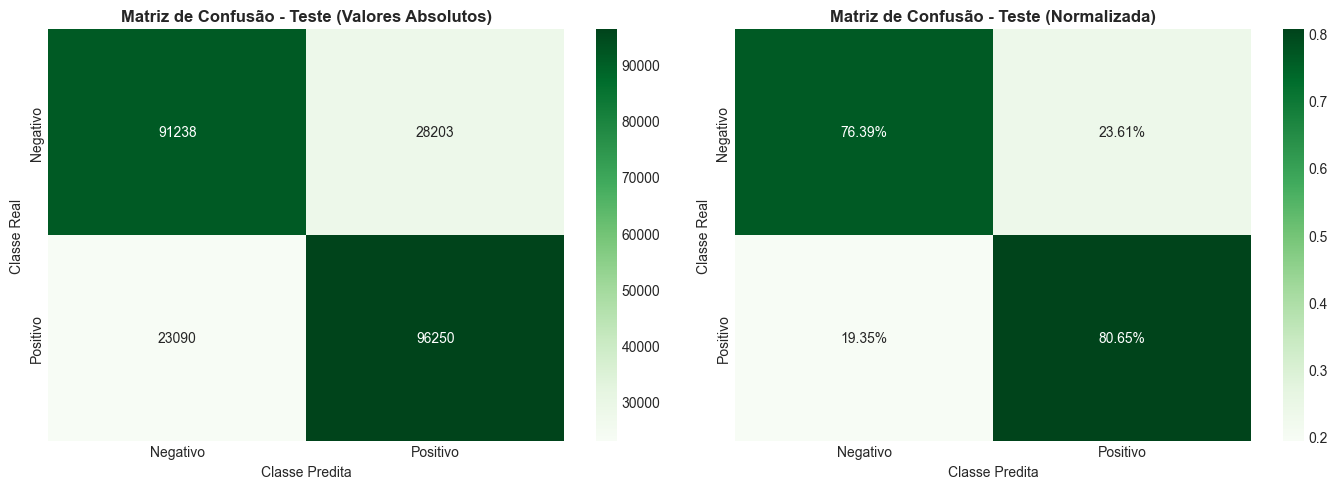

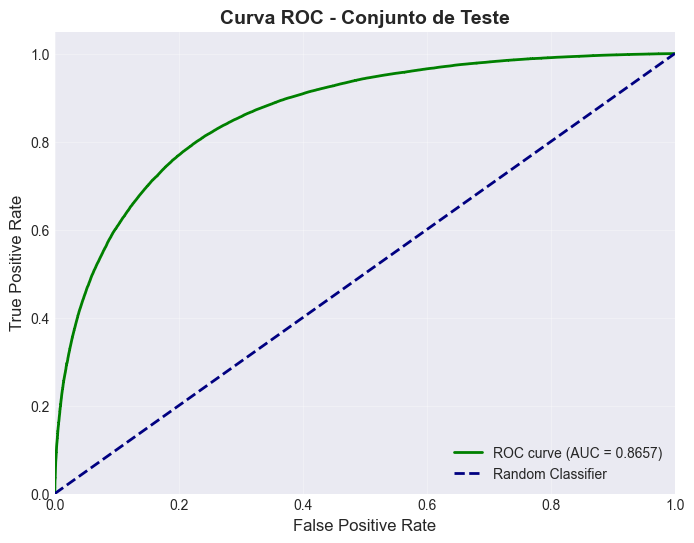

In [8]:
print("="*80)
print("AVALIAÇÃO NO CONJUNTO DE TESTE (DADOS NÃO VISTOS)")
print("="*80)

# Fazer predições
print(f"\n🔮 Gerando predições para teste...")
y_test_pred = model.predict(X_test_tfidf)
y_test_proba = model.predict_proba(X_test_tfidf)[:, 1]
print(f"✅ Predições geradas")

# Calcular métricas
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, y_test_proba)

print(f"\n📊 MÉTRICAS DE TESTE:")
print(f"   - Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"   - Precision: {test_precision:.4f}")
print(f"   - Recall:    {test_recall:.4f}")
print(f"   - F1-Score:  {test_f1:.4f}")
print(f"   - ROC-AUC:   {test_roc_auc:.4f}")

# Classification Report
print(f"\n📋 Classification Report (Teste):")
print(classification_report(y_test, y_test_pred, target_names=['Negativo (0)', 'Positivo (1)']))

# Confusion Matrix
cm_test = confusion_matrix(y_test, y_test_pred)
print(f"\n🔢 Matriz de Confusão (Teste):")
print(cm_test)

# Visualização da Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusão com valores absolutos
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['Negativo', 'Positivo'],
            yticklabels=['Negativo', 'Positivo'])
axes[0].set_title('Matriz de Confusão - Teste (Valores Absolutos)', fontweight='bold')
axes[0].set_ylabel('Classe Real')
axes[0].set_xlabel('Classe Predita')

# Matriz de confusão normalizada
cm_test_norm = cm_test.astype('float') / cm_test.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_test_norm, annot=True, fmt='.2%', cmap='Greens', ax=axes[1],
            xticklabels=['Negativo', 'Positivo'],
            yticklabels=['Negativo', 'Positivo'])
axes[1].set_title('Matriz de Confusão - Teste (Normalizada)', fontweight='bold')
axes[1].set_ylabel('Classe Real')
axes[1].set_xlabel('Classe Predita')

plt.tight_layout()
plt.show()

# Curva ROC
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr_test, tpr_test, color='green', lw=2, label=f'ROC curve (AUC = {test_roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Curva ROC - Conjunto de Teste', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


## 9. Comparação de Performance: Validação vs Teste


COMPARAÇÃO: VALIDAÇÃO vs TESTE

📊 Tabela Comparativa:


,Métrica,Validação,Teste,Diferença,Diferença (%)
0,Accuracy,0.783893,0.785188,0.001295,0.165198
1,Precision,0.773031,0.773384,0.000353,0.045654
2,Recall,0.803528,0.806519,0.002991,0.372290
3,F1-Score,0.787985,0.789604,0.001620,0.205547
4,ROC-AUC,0.865698,0.865741,0.000043,0.004967


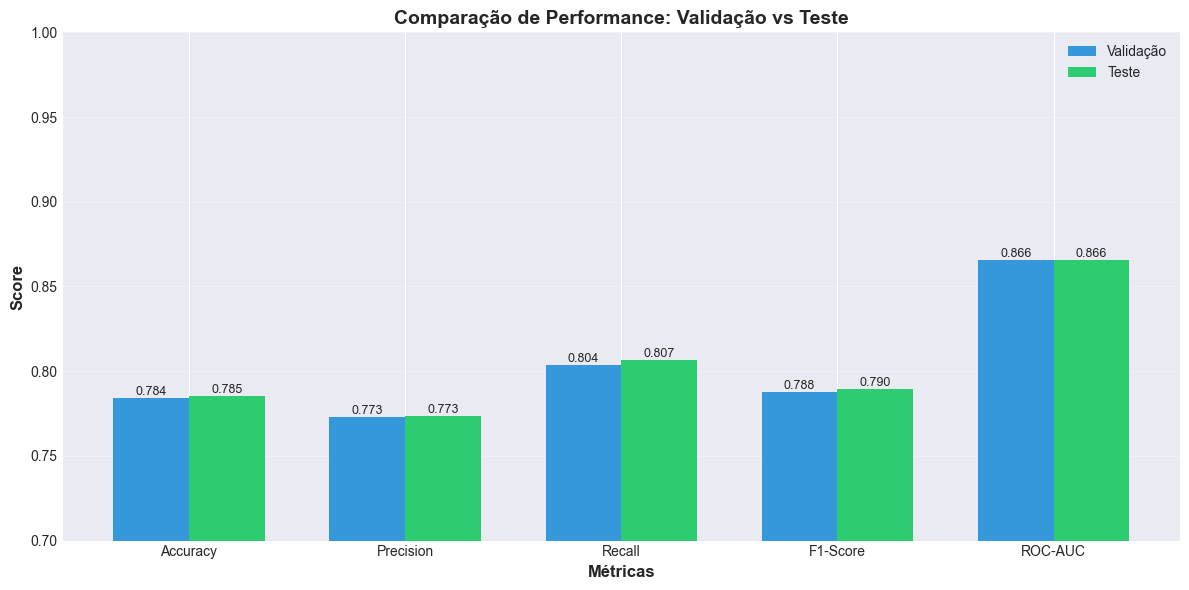


🔍 Análise de Generalização:
   - Diferença média absoluta: 0.0013
   - ✅ Excelente! Modelo está generalizando muito bem.


In [9]:
print("="*80)
print("COMPARAÇÃO: VALIDAÇÃO vs TESTE")
print("="*80)

# Criar DataFrame com comparação
metrics_comparison = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Validação': [val_accuracy, val_precision, val_recall, val_f1, val_roc_auc],
    'Teste': [test_accuracy, test_precision, test_recall, test_f1, test_roc_auc]
})

metrics_comparison['Diferença'] = metrics_comparison['Teste'] - metrics_comparison['Validação']
metrics_comparison['Diferença (%)'] = (metrics_comparison['Diferença'] / metrics_comparison['Validação']) * 100

print("\n📊 Tabela Comparativa:")
display(metrics_comparison)

# Visualização comparativa
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(metrics_comparison['Métrica']))
width = 0.35

bars1 = ax.bar(x - width/2, metrics_comparison['Validação'], width, label='Validação', color='#3498db')
bars2 = ax.bar(x + width/2, metrics_comparison['Teste'], width, label='Teste', color='#2ecc71')

ax.set_xlabel('Métricas', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Comparação de Performance: Validação vs Teste', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_comparison['Métrica'])
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0.7, 1.0])

# Adicionar valores no topo das barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Análise de overfitting/underfitting
avg_diff = metrics_comparison['Diferença'].abs().mean()
print(f"\n🔍 Análise de Generalização:")
print(f"   - Diferença média absoluta: {avg_diff:.4f}")

if avg_diff < 0.02:
    print(f"   - ✅ Excelente! Modelo está generalizando muito bem.")
elif avg_diff < 0.05:
    print(f"   - ✅ Bom! Modelo está generalizando bem.")
elif avg_diff < 0.10:
    print(f"   - ⚠️ Atenção! Pode haver leve overfitting.")
else:
    print(f"   - ❌ Cuidado! Possível overfitting detectado.")


## 10. Análise de Features Mais Importantes


ANÁLISE DE FEATURES IMPORTANTES

😊 Top 20 Features para SENTIMENTO POSITIVO:
    1. 'cant wait': 8.2748
    2. 'wish luck': 5.4902
    3. 'thank': 4.5197
    4. 'nothing wrong': 4.3428
    5. 'congratulation': 4.2865
    6. 'smiling': 4.1711
    7. 'thanks': 4.1641
    8. 'isnt bad': 4.1167
    9. 'smile': 3.9593
   10. 'proud': 3.9452
   11. 'wasnt bad': 3.9081
   12. 'dont forget': 3.8927
   13. 'welcome': 3.8829
   14. 'fair enough': 3.6733
   15. 'get enough': 3.6686
   16. 'glad': 3.6660
   17. 'yay': 3.5326
   18. 'hehe': 3.5156
   19. 'dont sad': 3.5082
   20. 'awesome': 3.5040

😢 Top 20 Features para SENTIMENTO NEGATIVO:
    1. 'sad': -10.7521
    2. 'sadly': -6.6813
    3. 'poor': -6.4974
    4. 'miss': -6.2318
    5. 'bummed': -6.1593
    6. 'unfortunately': -6.0343
    7. 'gutted': -6.0232
    8. 'disappointed': -6.0127
    9. 'sick': -5.9850
   10. 'rip': -5.9545
   11. 'died': -5.8223
   12. 'missing': -5.8204
   13. 'cant': -5.7179
   14. 'passed away': -5.6014
   15. 'ru

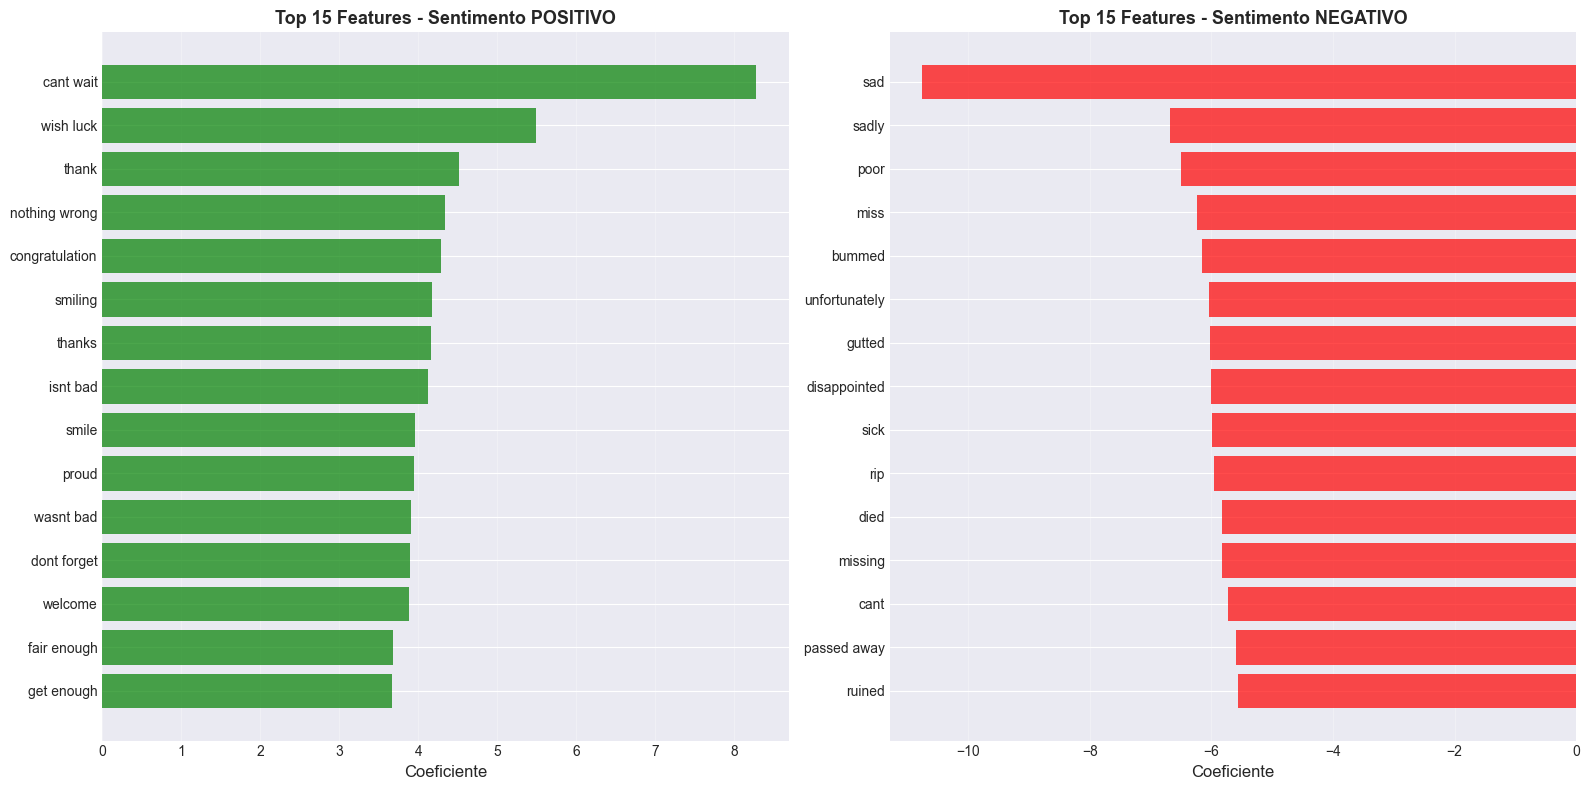

In [10]:
print("="*80)
print("ANÁLISE DE FEATURES IMPORTANTES")
print("="*80)

# Obter coeficientes e feature names
feature_names = vectorizer.get_feature_names_out()
coefficients = model.coef_[0]

# Top features para classe positiva (coeficientes mais altos)
top_positive_idx = np.argsort(coefficients)[-20:][::-1]
top_positive_features = [(feature_names[i], coefficients[i]) for i in top_positive_idx]

print(f"\n😊 Top 20 Features para SENTIMENTO POSITIVO:")
for i, (feature, coef) in enumerate(top_positive_features, 1):
    print(f"   {i:2d}. '{feature}': {coef:.4f}")

# Top features para classe negativa (coeficientes mais baixos)
top_negative_idx = np.argsort(coefficients)[:20]
top_negative_features = [(feature_names[i], coefficients[i]) for i in top_negative_idx]

print(f"\n😢 Top 20 Features para SENTIMENTO NEGATIVO:")
for i, (feature, coef) in enumerate(top_negative_features, 1):
    print(f"   {i:2d}. '{feature}': {coef:.4f}")

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Features positivas
pos_features = [f[0] for f in top_positive_features[:15]]
pos_coefs = [f[1] for f in top_positive_features[:15]]
axes[0].barh(range(len(pos_features)), pos_coefs, color='green', alpha=0.7)
axes[0].set_yticks(range(len(pos_features)))
axes[0].set_yticklabels(pos_features)
axes[0].set_xlabel('Coeficiente', fontsize=12)
axes[0].set_title('Top 15 Features - Sentimento POSITIVO', fontsize=13, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Features negativas
neg_features = [f[0] for f in top_negative_features[:15]]
neg_coefs = [f[1] for f in top_negative_features[:15]]
axes[1].barh(range(len(neg_features)), neg_coefs, color='red', alpha=0.7)
axes[1].set_yticks(range(len(neg_features)))
axes[1].set_yticklabels(neg_features)
axes[1].set_xlabel('Coeficiente', fontsize=12)
axes[1].set_title('Top 15 Features - Sentimento NEGATIVO', fontsize=13, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


## 11. Análise de Erros


ANÁLISE DE ERROS

📊 Estatísticas de Predição:
   - Predições corretas: 187,488 (78.52%)
   - Predições incorretas: 51,293 (21.48%)

🔍 Tipos de Erros:
   - Falsos Positivos (predito positivo, real negativo): 28,203
   - Falsos Negativos (predito negativo, real positivo): 23,090

❌ Exemplos de FALSOS POSITIVOS (modelo disse positivo, mas era negativo):

1. Texto: 'im exactly round illness taught sometimes cant fight naturally good luck girl...'
   Real: NEGATIVO | Predito: POSITIVO | Confiança: 52.70%

2. Texto: 'happy saturday study...'
   Real: NEGATIVO | Predito: POSITIVO | Confiança: 81.39%

3. Texto: 'th woooooow got th lol...'
   Real: NEGATIVO | Predito: POSITIVO | Confiança: 73.35%

4. Texto: 'sittin interstate waiting wi trooper finish running plate wonder ill get speeding ticket stay tuned...'
   Real: NEGATIVO | Predito: POSITIVO | Confiança: 59.68%

5. Texto: 'kno cud tell...'
   Real: NEGATIVO | Predito: POSITIVO | Confiança: 53.69%

6. Texto: 'somebody please bring back mag

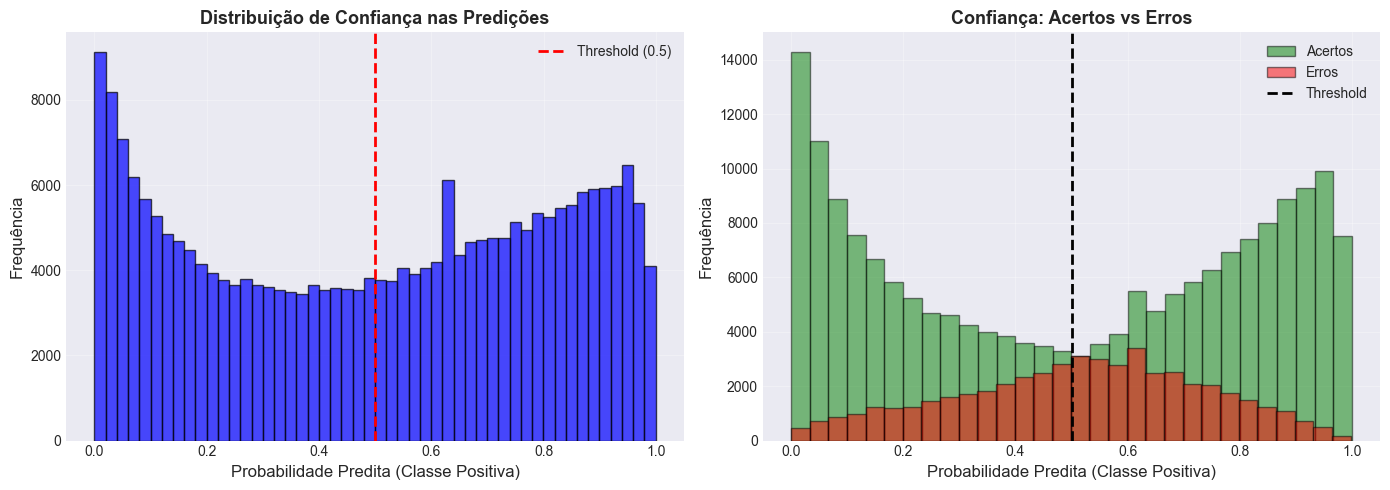

In [11]:
print("="*80)
print("ANÁLISE DE ERROS")
print("="*80)

# Identificar erros
errors_idx = np.where(y_test != y_test_pred)[0]
correct_idx = np.where(y_test == y_test_pred)[0]

print(f"\n📊 Estatísticas de Predição:")
print(f"   - Predições corretas: {len(correct_idx):,} ({len(correct_idx)/len(y_test)*100:.2f}%)")
print(f"   - Predições incorretas: {len(errors_idx):,} ({len(errors_idx)/len(y_test)*100:.2f}%)")

# Analisar tipos de erros
false_positives = np.where((y_test == 0) & (y_test_pred == 1))[0]
false_negatives = np.where((y_test == 1) & (y_test_pred == 0))[0]

print(f"\n🔍 Tipos de Erros:")
print(f"   - Falsos Positivos (predito positivo, real negativo): {len(false_positives):,}")
print(f"   - Falsos Negativos (predito negativo, real positivo): {len(false_negatives):,}")

# Mostrar exemplos de erros
print(f"\n❌ Exemplos de FALSOS POSITIVOS (modelo disse positivo, mas era negativo):")
for i, idx in enumerate(false_positives[:10], 1):
    confidence = y_test_proba[idx]
    text = X_test[idx][:150]
    print(f"\n{i}. Texto: '{text}...'")
    print(f"   Real: NEGATIVO | Predito: POSITIVO | Confiança: {confidence:.2%}")

print(f"\n{'='*80}")
print(f"\n❌ Exemplos de FALSOS NEGATIVOS (modelo disse negativo, mas era positivo):")
for i, idx in enumerate(false_negatives[:10], 1):
    confidence = y_test_proba[idx]
    text = X_test[idx][:150]
    print(f"\n{i}. Texto: '{text}...'")
    print(f"   Real: POSITIVO | Predito: NEGATIVO | Confiança: {1-confidence:.2%}")

# Distribuição de confiança nas predições
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de confiança geral
axes[0].hist(y_test_proba, bins=50, color='blue', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Probabilidade Predita (Classe Positiva)', fontsize=12)
axes[0].set_ylabel('Frequência', fontsize=12)
axes[0].set_title('Distribuição de Confiança nas Predições', fontsize=13, fontweight='bold')
axes[0].axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Threshold (0.5)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Confiança separada por acertos e erros
correct_proba = y_test_proba[correct_idx]
error_proba = y_test_proba[errors_idx]

axes[1].hist(correct_proba, bins=30, color='green', alpha=0.5, label='Acertos', edgecolor='black')
axes[1].hist(error_proba, bins=30, color='red', alpha=0.5, label='Erros', edgecolor='black')
axes[1].set_xlabel('Probabilidade Predita (Classe Positiva)', fontsize=12)
axes[1].set_ylabel('Frequência', fontsize=12)
axes[1].set_title('Confiança: Acertos vs Erros', fontsize=13, fontweight='bold')
axes[1].axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Threshold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 12. Resumo Final e Conclusões


In [12]:
print("="*80)
print("RESUMO FINAL DO MODELO BASELINE")
print("="*80)

print(f"\n📊 CONFIGURAÇÃO DO EXPERIMENTO:")
print(f"   - Dataset: sentiment140_preprocessed.csv")
print(f"   - Total de amostras: {len(df):,}")
print(f"   - Divisão: {len(X_train):,} treino / {len(X_val):,} validação / {len(X_test):,} teste")
print(f"   - Vetorização: TF-IDF (max_features={tfidf_params['max_features']}, ngrams={tfidf_params['ngram_range']})")
print(f"   - Modelo: Logistic Regression (solver={model_params['solver']}, C={model_params['C']})")
print(f"   - Tempo de treinamento: {duration:.2f} segundos")

print(f"\n🎯 PERFORMANCE FINAL (CONJUNTO DE TESTE):")
print(f"   - Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"   - Precision: {test_precision:.4f}")
print(f"   - Recall:    {test_recall:.4f}")
print(f"   - F1-Score:  {test_f1:.4f}")
print(f"   - ROC-AUC:   {test_roc_auc:.4f}")

print(f"\n📈 ANÁLISE DE GENERALIZAÇÃO:")
print(f"   - Diferença Val-Test (Accuracy): {abs(val_accuracy - test_accuracy):.4f}")
print(f"   - Diferença Val-Test (F1): {abs(val_f1 - test_f1):.4f}")

if abs(val_accuracy - test_accuracy) < 0.02:
    print(f"   - ✅ Modelo está generalizando muito bem!")
else:
    print(f"   - ⚠️ Há alguma diferença entre validação e teste")

print(f"\n💡 PRÓXIMOS PASSOS RECOMENDADOS:")
print(f"   1. Experimentar com diferentes valores de C (regularização)")
print(f"   2. Testar outros classificadores (SVM, Random Forest, etc.)")
print(f"   3. Ajustar parâmetros do TF-IDF (max_features, ngrams)")
print(f"   4. Implementar modelos mais avançados (BERT, Transformers)")
print(f"   5. Realizar análise de erros mais profunda")

print(f"\n" + "="*80)
print(f"EXPERIMENTO CONCLUÍDO COM SUCESSO! ✅")
print(f"Timestamp final: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*80)


RESUMO FINAL DO MODELO BASELINE

📊 CONFIGURAÇÃO DO EXPERIMENTO:
   - Dataset: sentiment140_preprocessed.csv
   - Total de amostras: 1,591,869
   - Divisão: 1,114,308 treino / 238,780 validação / 238,781 teste
   - Vetorização: TF-IDF (max_features=10000, ngrams=(1, 2))
   - Modelo: Logistic Regression (solver=saga, C=1.0)
   - Tempo de treinamento: 15.72 segundos

🎯 PERFORMANCE FINAL (CONJUNTO DE TESTE):
   - Accuracy:  0.7852 (78.52%)
   - Precision: 0.7734
   - Recall:    0.8065
   - F1-Score:  0.7896
   - ROC-AUC:   0.8657

📈 ANÁLISE DE GENERALIZAÇÃO:
   - Diferença Val-Test (Accuracy): 0.0013
   - Diferença Val-Test (F1): 0.0016
   - ✅ Modelo está generalizando muito bem!

💡 PRÓXIMOS PASSOS RECOMENDADOS:
   1. Experimentar com diferentes valores de C (regularização)
   2. Testar outros classificadores (SVM, Random Forest, etc.)
   3. Ajustar parâmetros do TF-IDF (max_features, ngrams)
   4. Implementar modelos mais avançados (BERT, Transformers)
   5. Realizar análise de erros mais